# Complex-Network VM PDFs with Delta Resetting

This notebook sweeps the empirical magnetization PDF of the voter model with **delta resetting only** on complex networks.

**Initial condition: Reset state** — each simulation starts from the spin configuration resulting from the delta-reset protocol.

Swept dimensions:
- reset rate `r`,
- delta-reset target magnetization `m_reset` (determines initial spin configuration),
- graph topology (ER and RRG),
- expected degree `mu`.

Use `quick_mode = true` first to validate speed, then switch to full settings.

In [1]:
using Graphs
using Random
using Statistics
using Printf
using Plots

project_root = isdir(joinpath(pwd(), "src")) ? pwd() : dirname(dirname(pwd()))
include(joinpath(project_root, "src", "VoterResetting.jl"))

default(; legendfontsize=8, guidefontsize=10, tickfontsize=8, titlefontsize=11)
println("Loaded VoterResetting from: $(joinpath(project_root, "src", "VoterResetting.jl"))")

Loaded VoterResetting from: c:\Users\gerar\Desktop\Escola\Universitat\Master\TFM\voter-model-stochastic-resetting\src\VoterResetting.jl


In [2]:
# ---------------------------
# Sweep controls
# ---------------------------
quick_mode = false

if quick_mode
    N = 350
    nsamples = 140
    mu_values = [6, 20]
    r_values = [0.0, 0.5, 3.0]
    m_reset_values = [0.0, 0.9]
    times = [2.5]
    bins = 50
else
    N = 800
    nsamples = 3000
    mu_values = [4, 10, 30]
    r_values = [0.0, 10.0, 100.0]
    m_reset_values = [0.0, 0.5]
    times = [100.0]
    bins = 70
end

topologies = [:ER, :RRG, :BA]

function build_graph(topology::Symbol, N::Int, mu::Int)
    if topology == :ER
        return erdos_renyi(N, mu / (N - 1))
    elseif topology == :RRG
        iseven(N * mu) || throw(ArgumentError("RRG requires N*mu even. Got N=$N, mu=$mu"))
        return random_regular_graph(N, mu)
    elseif topology == :BA
        m_attach = max(1, Int(round(mu / 2)))
        return barabasi_albert(N, m_attach)
    else
        throw(ArgumentError("Unknown topology: $topology"))
    end
end

function run_pdf_case(; topology::Symbol, N::Int, mu::Int, r::Float64, m_reset::Float64,
        times::Vector{Float64}, bins, nsamples::Int)
    G = build_graph(topology, N, mu)
    # Initial condition: use reset state, so m0 = m_reset
    params = VoterResetting.ComplexParams(r, m_reset)

    result = VoterResetting.simulate_pdf_complex(
        G, params;
        reset = VoterResetting.delta_reset(m_reset),
        times = times,
        bins = bins,
        nsamples = nsamples,
        value_range = (-1.0, 1.0),
    )

    return result
end

println("Sweep setup:")
println("  quick_mode          = $(quick_mode)")
println("  topologies          = $(topologies)")
println("  mu_values           = $(mu_values)")
println("  r_values            = $(r_values)")
println("  m_reset_vals        = $(m_reset_values)  (initial condition = reset state)")
println("  N                   = $(N), nsamples = $(nsamples), bins = $(bins), times = $(times)")

Sweep setup:
  quick_mode          = false
  topologies          = [:ER, :RRG, :BA]
  mu_values           = [4, 10, 30]
  r_values            = [0.0, 10.0, 100.0]
  m_reset_vals        = [0.0, 0.5]  (initial condition = reset state)
  N                   = 800, nsamples = 3000, bins = 70, times = [100.0]


In [ ]:
# ---------------------------
# Run full parameter sweep
# ---------------------------
# Key format: (topology, mu, r, m_reset)
pdf_results = Dict{NTuple{4, Any}, VoterResetting.PDFSimulationResult}()

total_cases = length(topologies) * length(mu_values) * length(r_values) * length(m_reset_values)
case_counter = 0

for topo in topologies
    for mu in mu_values
        for r in r_values
            for m_reset in m_reset_values
                case_counter += 1
                println(@sprintf("[%3d/%3d] topo=%s mu=%d r=%.3f m_reset=%.2f (initial cond = reset state)", case_counter, total_cases, string(topo), mu, r, m_reset))
                key = (topo, mu, r, m_reset)
                pdf_results[key] = run_pdf_case(
                    topology=topo, N=N, mu=mu, r=r, m_reset=m_reset,
                    times=times, bins=bins, nsamples=nsamples,
                )
            end
        end
    end
end

println(@sprintf("Done. Stored %d PDF cases.", length(pdf_results)))

[  1/ 54] topo=ER mu=4 r=0.000 m_reset=0.00 (initial cond = reset state)
[  2/ 54] topo=ER mu=4 r=0.000 m_reset=0.50 (initial cond = reset state)
[  3/ 54] topo=ER mu=4 r=10.000 m_reset=0.00 (initial cond = reset state)
[  4/ 54] topo=ER mu=4 r=10.000 m_reset=0.50 (initial cond = reset state)
[  5/ 54] topo=ER mu=4 r=100.000 m_reset=0.00 (initial cond = reset state)


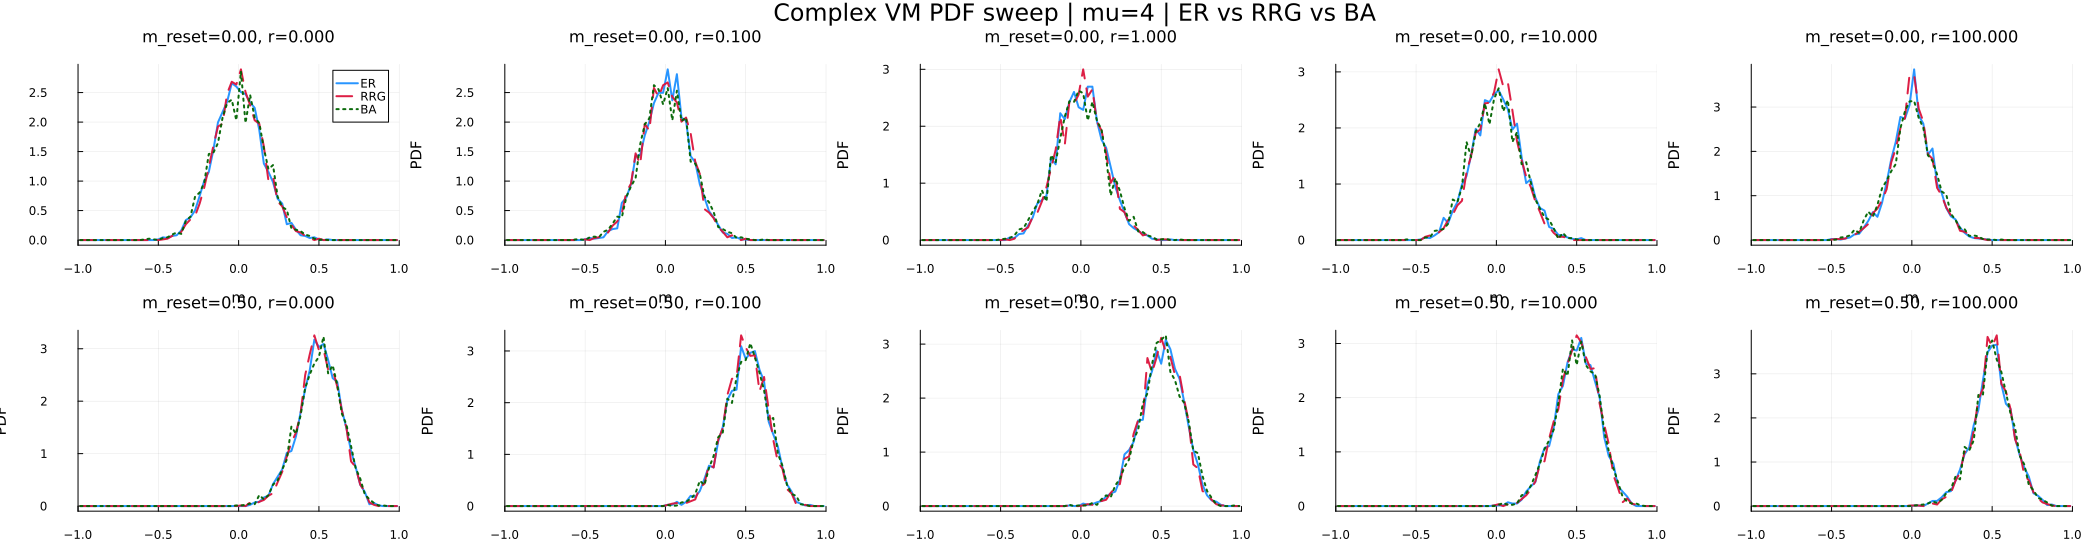

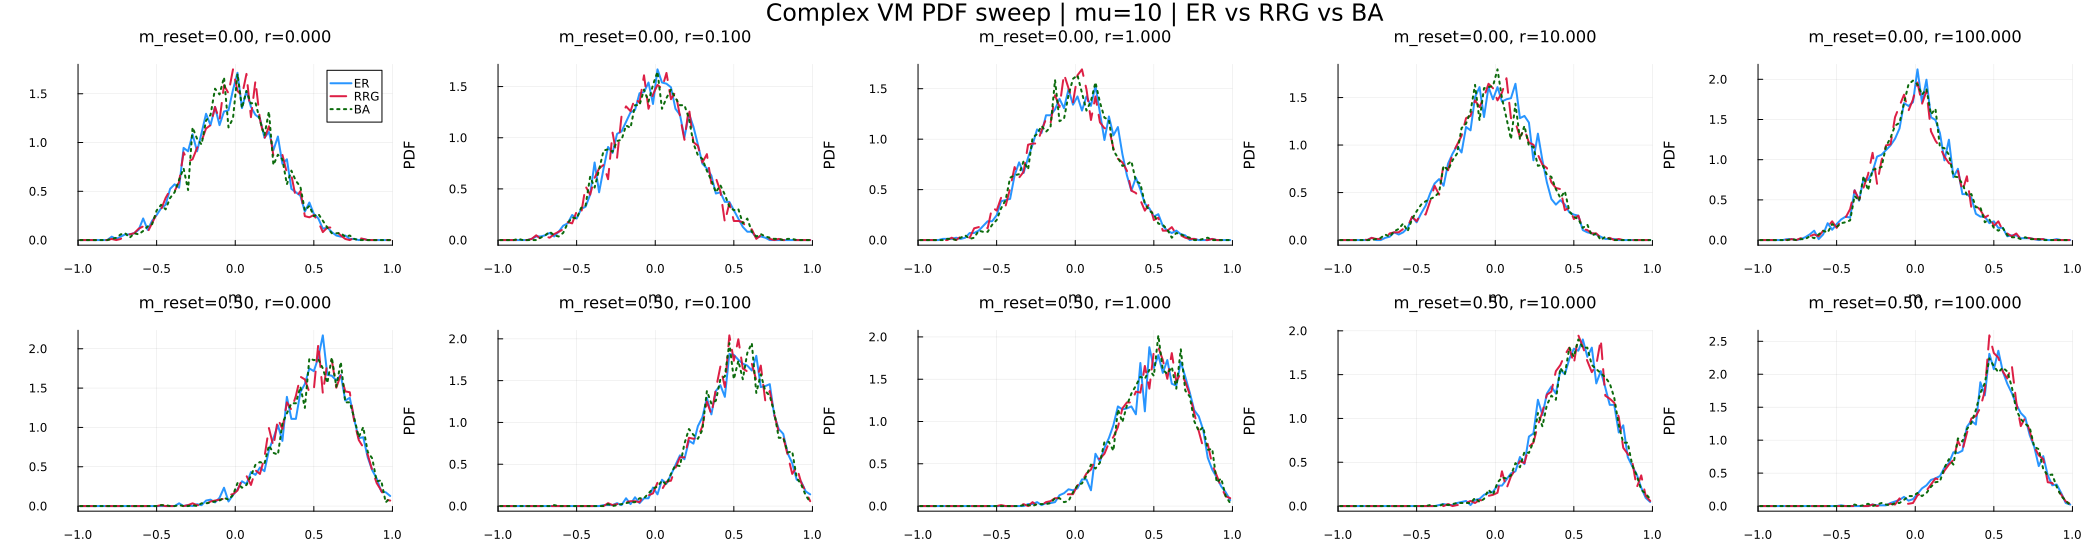

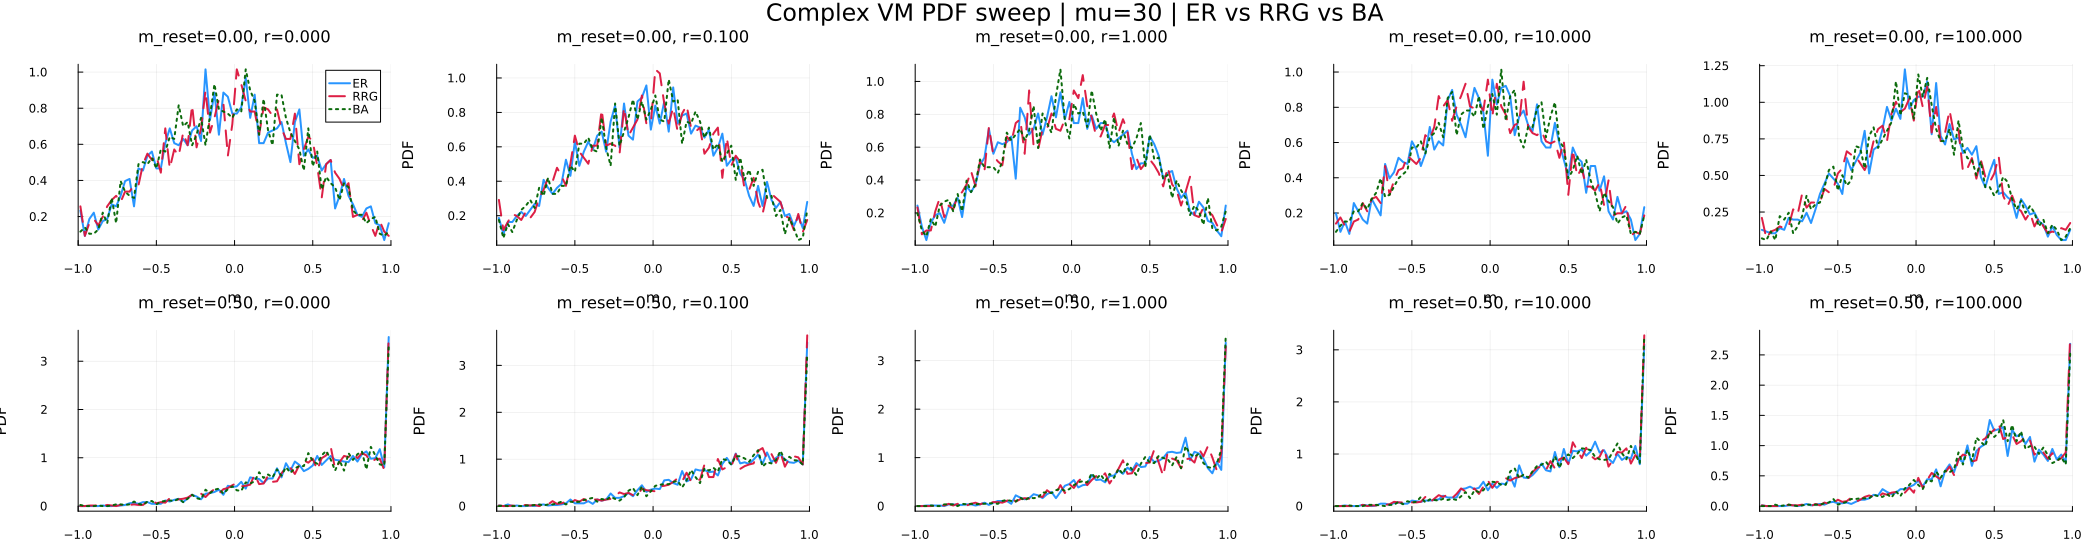

In [ ]:
# ---------------------------
# Plotting: one figure per mu, with ER/RRG/BA overlaid in each panel
# Rows = m_reset values, Cols = r values
# Curves in each panel = different topologies
# ---------------------------
topology_colors = Dict(:ER => :dodgerblue, :RRG => :crimson, :BA => :darkgreen)
topology_styles = Dict(:ER => :solid, :RRG => :dash, :BA => :dot)
topology_order = [:ER, :RRG, :BA]

for mu in mu_values
    nrows = length(m_reset_values)
    ncols = length(r_values)
    p = plot(layout=(nrows, ncols), size=(420 * ncols, 280 * nrows), margin=5Plots.mm)

    for (i_reset, m_reset) in enumerate(m_reset_values)
        for (j_r, r) in enumerate(r_values)
            panel_idx = (i_reset - 1) * ncols + j_r
            for topo in topology_order
                key = (topo, mu, r, m_reset)
                res = pdf_results[key]
                x = res.bin_centers
                y = vec(res.densities[1, :])
                plot!(p[panel_idx], x, y; lw=2.0, color=topology_colors[topo], ls=topology_styles[topo], alpha=0.95,
                    label=(panel_idx == 1 ? string(topo) : ""))
            end
            title!(p[panel_idx], @sprintf("m_reset=%.2f, r=%.3f", m_reset, r))
            xlabel!(p[panel_idx], "m")
            ylabel!(p[panel_idx], "PDF")
            xlims!(p[panel_idx], -1, 1)
            plot!(p[panel_idx]; grid=true)
        end
    end

    plot!(p; legend=:topright)
    display(plot(p; plot_title=@sprintf("Complex VM PDF sweep | mu=%d | ER vs RRG vs BA", mu)))
end